## 1) Baseline de Regressão Logística

**Objetivo:** treinar um modelo simples de regressão logística e avaliar o desempenho no conjunto de teste.

## 1.1) Importação de bibliotecas e leitura dos dados

In [100]:
# importações de bibliotecas
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 2) Preparação dos dados

In [101]:
# alteração do tipo de dados
ortho_clean["Grupo_pre"] = ortho_clean["Grupo_pre"].astype("category")
ortho_clean["Sexo"] = ortho_clean["Sexo"].astype("category")
ortho_clean["mudanca_CPAK"] = ortho_clean["mudanca_CPAK"].astype("category")

# one hot encoding apenas para "grupo_pre" pois apresenta mais de 2 categorias
categorical_features = ["Grupo_pre"]
ortho_clean = pd.get_dummies(ortho_clean, columns=categorical_features, drop_first=True)

# definir preditores e target
X = ortho_clean.drop("mudanca_CPAK", axis=1)
y = ortho_clean["mudanca_CPAK"]

# split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)



In [102]:
# Verificação da distribuição da target no conjunto de treino
print("Distribuição da Target (CPAK) - Treino")
print("N. observações Treino", len(X_train))
print(y_train.value_counts(normalize=True))

Distribuição da Target (CPAK) - Treino
N. observações Treino 183
mudanca_CPAK
False    0.901639
True     0.098361
Name: proportion, dtype: float64


In [103]:
# Verificação da distribuição da target no conjunto de teste

print("Distribuição da Target (CPAK) - Teste")
print("N. observações Teste", len(X_test))
print(y_test.value_counts(normalize=True))

Distribuição da Target (CPAK) - Teste
N. observações Teste 79
mudanca_CPAK
False    0.898734
True     0.101266
Name: proportion, dtype: float64


## 3) Baseline de Regressão Logística

In [104]:
# Treino do baseline com Regressão Logística
clf_LR = LogisticRegression(random_state=42)
clf_LR = clf_LR.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_LR = clf_LR.predict(X_test)
y_pred_LR_prob = clf_LR.predict_proba(X_test)
print(y_pred_LR_prob)
print(y_pred_LR)

[[9.93630627e-01 6.36937279e-03]
 [9.95410805e-01 4.58919483e-03]
 [9.99755509e-01 2.44491202e-04]
 [9.63996664e-01 3.60033359e-02]
 [9.93304308e-01 6.69569186e-03]
 [9.91663028e-01 8.33697246e-03]
 [9.57802531e-01 4.21974687e-02]
 [9.95710518e-01 4.28948198e-03]
 [2.36359293e-01 7.63640707e-01]
 [8.43238675e-01 1.56761325e-01]
 [9.99621647e-01 3.78352710e-04]
 [8.82172800e-01 1.17827200e-01]
 [9.95079812e-01 4.92018820e-03]
 [9.99344093e-01 6.55906553e-04]
 [9.97868052e-01 2.13194775e-03]
 [9.97563543e-01 2.43645660e-03]
 [8.74773751e-01 1.25226249e-01]
 [9.92756145e-01 7.24385518e-03]
 [9.99984494e-01 1.55062979e-05]
 [9.98900344e-01 1.09965643e-03]
 [9.73063337e-01 2.69366629e-02]
 [9.99941554e-01 5.84457627e-05]
 [5.82565053e-01 4.17434947e-01]
 [9.82146494e-01 1.78535063e-02]
 [9.37540677e-01 6.24593226e-02]
 [9.94989258e-01 5.01074176e-03]
 [9.84658638e-01 1.53413616e-02]
 [9.96635469e-01 3.36453062e-03]
 [9.87869169e-01 1.21308309e-02]
 [2.31480332e-01 7.68519668e-01]
 [9.185263

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


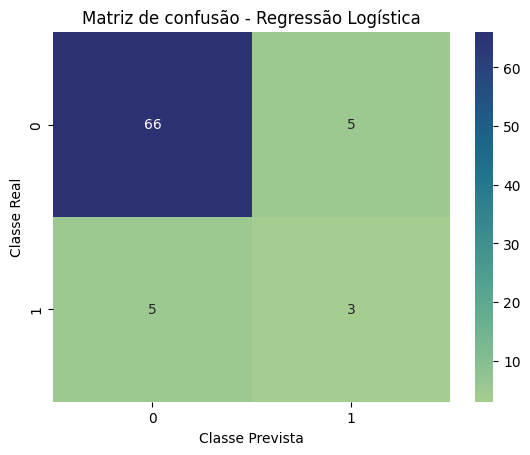

In [105]:
# Matriz de confusão do baseline (Regressão Logística)
c_matrix_LR = confusion_matrix(y_test, y_pred_LR)

# Visualização da matriz de confusão
sns.heatmap(c_matrix_LR, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.title('Matriz de confusão - Regressão Logística')
plt.show()

In [106]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_LR))

# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_LR)
print('AUC:', auc)

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        71
         1.0       0.38      0.38      0.38         8

    accuracy                           0.87        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.87      0.87      0.87        79

AUC: 0.6522887323943661


In [107]:
# Validação cruzada (Stratified K-fold) para estimar generalização
pred = cross_val_predict(
    clf_LR,
    X_train,
    y_train,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 )
print(classification_report(y_train, pred, digits=4))



              precision    recall  f1-score   support

         0.0     0.9290    0.9515    0.9401       165
         1.0     0.4286    0.3333    0.3750        18

    accuracy                         0.8907       183
   macro avg     0.6788    0.6424    0.6576       183
weighted avg     0.8798    0.8907    0.8845       183



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [108]:
#coefientes do modelo para análise de importância das features

coef_LR = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': clf_LR.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)

coef_LR.head(10)

,Variavel,Coeficiente
15,Grupo_pre_5,0.450697
12,Grupo_pre_2,0.443417
13,Grupo_pre_3,-0.407039
14,Grupo_pre_4,-0.365322
9,WR_0,0.190877
8,WD_0,-0.152076
4,IMC,-0.150906
6,EVA_0,0.113656
0,Idade,-0.106804
17,Grupo_pre_7,-0.096873


## 4) Teste de Redundância de Variáveis

Nesta secção avaliamos se algumas variáveis estão a representar a mesma informação e se podem ser removidas sem perda relevante de desempenho. Na análise exploratória de dados verificou-se a existência de variáveis que eram altamente correlacionadas entre si.

- Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)
- Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

Objetivo: identificar a forma mais simples de representar os dados, reduzindo redundância e mantendo qualidade preditiva.

### 4.1) WT_0 vs os seus componentes

WT_0 é composto pela adição dos seus componentes (WR_0, WD_0 e WAtotal_0).

### 4.1.1) Avaliação da remoção da variavel WT_0:


c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


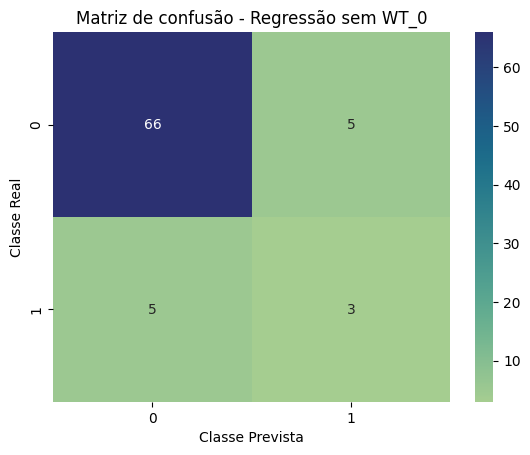

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        71
         1.0       0.38      0.38      0.38         8

    accuracy                           0.87        79
   macro avg       0.65      0.65      0.65        79
weighted avg       0.87      0.87      0.87        79

AUC sem WT_0: 0.6522887323943661
=== Stratified K-fold (sem WT_0) ===
              precision    recall  f1-score   support

         0.0     0.9298    0.9636    0.9464       165
         1.0     0.5000    0.3333    0.4000        18

    accuracy                         0.9016       183
   macro avg     0.7149    0.6485    0.6732       183
weighted avg     0.8875    0.9016    0.8927       183



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [109]:
# preparar os dados para treinar o modelo sem WT_0
x_train_sem_WT0 = X_train.drop('WT_0', axis=1)
x_test_sem_WT0 = X_test.drop('WT_0', axis=1)

# Treino do modelo sem WT_0
clf_LR_sem_WT0 = LogisticRegression(random_state=42)
clf_LR_sem_WT0 = clf_LR_sem_WT0.fit(x_train_sem_WT0, y_train)

# previsões
y_pred_LR_sem_WT0 = clf_LR_sem_WT0.predict(x_test_sem_WT0)

# avaliação de métricas para o modelo sem WT_0
# matriz de confusao para o modelo sem WT_0
confusion_sem_WT0 = confusion_matrix(y_test, y_pred_LR_sem_WT0)
sns.heatmap(confusion_sem_WT0, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0")
plt.show()

#curva ROC e AUC para o modelo sem WT_0
print(classification_report(y_test, y_pred_LR_sem_WT0))
auc_sem_WT0 = roc_auc_score(y_test, y_pred_LR_sem_WT0)
print("AUC sem WT_0:", auc_sem_WT0)

# k-fold estratificado para o modelo sem WT_0
# k-fold estratificado para o modelo sem WT_0
pred_cross_sem_WT0 = cross_val_predict(
    clf_LR_sem_WT0,
    X_train.drop('WT_0', axis=1),
    y_train,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)
print("=== Stratified K-fold (sem WT_0) ===")
print(classification_report(y_train, pred_cross_sem_WT0, digits=4))

### 4.1.2) Avaliação da remoção dos componentes WR_0, WD_0 e WATotal_0

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

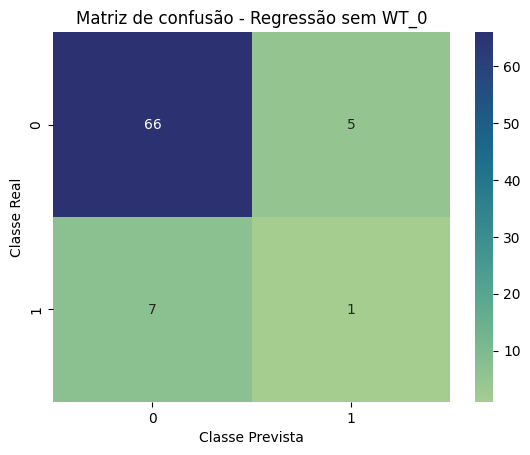

              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92        71
         1.0       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC sem componentes: 0.5272887323943662
=== Stratified K-fold (sem componentes) ===
              precision    recall  f1-score   support

         0.0     0.9032    0.9492    0.9256       236
         1.0     0.1429    0.0769    0.1000        26

    accuracy                         0.8626       262
   macro avg     0.5230    0.5130    0.5128       262
weighted avg     0.8278    0.8626    0.8437       262



In [110]:
# avaliação sem os componentes
# preparar os dados para treinar o modelo sem WR_0, WD_0 e WATotal_0
x_train_sem_comp = X_train.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1)
x_test_sem_comp = X_test.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1)

# Treino do modelo sem WT_0
clf_LR_sem_comp = LogisticRegression(random_state=42)
clf_LR_sem_comp = clf_LR_sem_comp.fit(x_train_sem_comp, y_train)

# previsões
y_pred_LR_sem_comp = clf_LR_sem_comp.predict(x_test_sem_comp)

# k-fold estratificado para o modelo sem WT_0
pred_cross_sem_comp = cross_val_predict(
    clf_LR_sem_comp,
    X.drop(['WR_0', 'WD_0', 'WAtotal_0'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)

# avaliação de métricas para o modelo sem os componentes

# matriz de confusão para o modelo sem os componentes
confusion_sem_comp = confusion_matrix(y_test, y_pred_LR_sem_comp)
sns.heatmap(confusion_sem_comp, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0")
plt.show()

# curva ROC e AUC para o modelo sem os componentes
print(classification_report(y_test, y_pred_LR_sem_comp))
auc_sem_comp = roc_auc_score(y_test, y_pred_LR_sem_comp)
print("AUC sem componentes:", auc_sem_comp)

# K-fold estratificado para o modelo sem os componentes
print("=== Stratified K-fold (sem componentes) ===")
print(classification_report(y, pred_cross_sem_comp, digits=4))


# 4.2) IMc vs Peso/Altura_cm



### 4.2.1) Avaliação da remoção de IMC

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


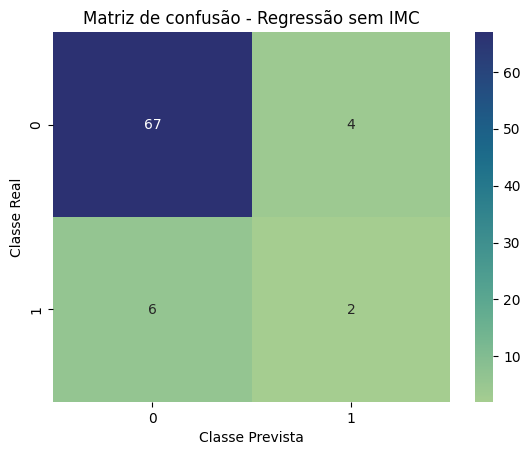

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93        71
         1.0       0.33      0.25      0.29         8

    accuracy                           0.87        79
   macro avg       0.63      0.60      0.61        79
weighted avg       0.86      0.87      0.87        79

AUC sem IMC: 0.5968309859154929
=== Stratified K-fold (sem IMC) ===
              precision    recall  f1-score   support

         0.0     0.9012    0.9661    0.9325       236
         1.0     0.1111    0.0385    0.0571        26

    accuracy                         0.8740       262
   macro avg     0.5061    0.5023    0.4948       262
weighted avg     0.8228    0.8740    0.8456       262



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [111]:
# avaliação sem o IMC
# preparar os dados para treinar o modelo sem IMC
x_train_sem_IMC = X_train.drop(['IMC'], axis=1)
x_test_sem_IMC = X_test.drop(['IMC'], axis=1)

# Treino do modelo sem IMC
clf_LR_sem_IMC = LogisticRegression(random_state=42)
clf_LR_sem_IMC = clf_LR_sem_IMC.fit(x_train_sem_IMC, y_train)

# previsões
y_pred_LR_sem_IMC = clf_LR_sem_IMC.predict(x_test_sem_IMC)

# avaliação de métricas para o modelo sem IMC
# matriz de confusão para o modelo sem IMC
confusion_sem_IMC = confusion_matrix(y_test, y_pred_LR_sem_IMC)
sns.heatmap(confusion_sem_IMC, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem IMC")
plt.show()

# curva ROC e AUC para o modelo sem IMC
print(classification_report(y_test, y_pred_LR_sem_IMC))
auc_sem_IMC = roc_auc_score(y_test, y_pred_LR_sem_IMC)
print("AUC sem IMC:", auc_sem_IMC)

# K-fold estratificado para o modelo sem IMC
pred_cross_sem_IMC = cross_val_predict(
    clf_LR_sem_IMC,
    X.drop(['IMC'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)
print("=== Stratified K-fold (sem IMC) ===")
print(classification_report(y, pred_cross_sem_IMC, digits=4))


### 4.2.2) Avaliação da remoção do Peso e Altura_cm

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


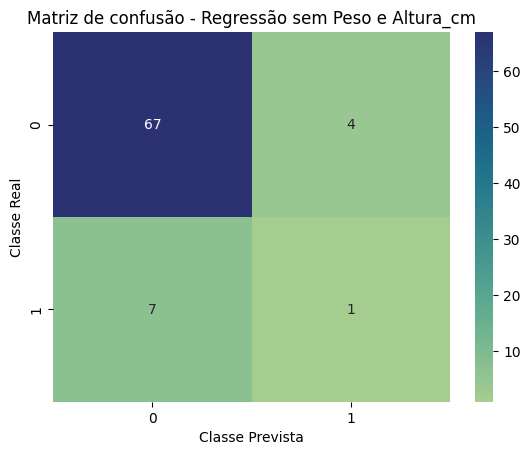

              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92        71
         1.0       0.20      0.12      0.15         8

    accuracy                           0.86        79
   macro avg       0.55      0.53      0.54        79
weighted avg       0.83      0.86      0.85        79

AUC sem Peso e Altura_cm: 0.5343309859154929
=== Stratified K-fold (sem Peso e Altura_cm) ===
              precision    recall  f1-score   support

         0.0     0.9076    0.9576    0.9320       236
         1.0     0.2308    0.1154    0.1538        26

    accuracy                         0.8740       262
   macro avg     0.5692    0.5365    0.5429       262
weighted avg     0.8405    0.8740    0.8547       262



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [112]:
# avaliação sem Peso e Altura_cm
# preparar os dados para treinar o modelo sem Peso e Altura_cm
x_train_sem_peso_altura = X_train.drop(['Peso', 'Altura_cm'], axis=1)
x_test_sem_peso_altura = X_test.drop(['Peso', 'Altura_cm'], axis=1)

# Treino do modelo sem Peso e Altura_cm
clf_LR_sem_peso_altura = LogisticRegression(random_state=42)
clf_LR_sem_peso_altura = clf_LR_sem_peso_altura.fit(x_train_sem_peso_altura, y_train)

# previsões
y_pred_LR_sem_peso_altura = clf_LR_sem_peso_altura.predict(x_test_sem_peso_altura)

# avaliação de métricas para o modelo sem os componentes
# matriz de confusão para o modelo sem os componentes
confusion_sem_peso_altura = confusion_matrix(y_test, y_pred_LR_sem_peso_altura)
sns.heatmap(confusion_sem_peso_altura, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem Peso e Altura_cm")
plt.show()

# curva ROC e AUC para o modelo sem os componentes
print(classification_report(y_test, y_pred_LR_sem_peso_altura))
auc_sem_peso_altura = roc_auc_score(y_test, y_pred_LR_sem_peso_altura)
print("AUC sem Peso e Altura_cm:", auc_sem_peso_altura)

# K-fold estratificado para o modelo sem os componentes
# k-fold estratificado para o modelo sem Peso e Altura_cm
pred_cross_sem_peso_altura = cross_val_predict(
    clf_LR_sem_peso_altura,
    X.drop(['Peso', 'Altura_cm'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)
print("=== Stratified K-fold (sem Peso e Altura_cm) ===")
print(classification_report(y, pred_cross_sem_peso_altura, digits=4))


## 4.3) Remoção simultânea de IMC e WT_0

c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


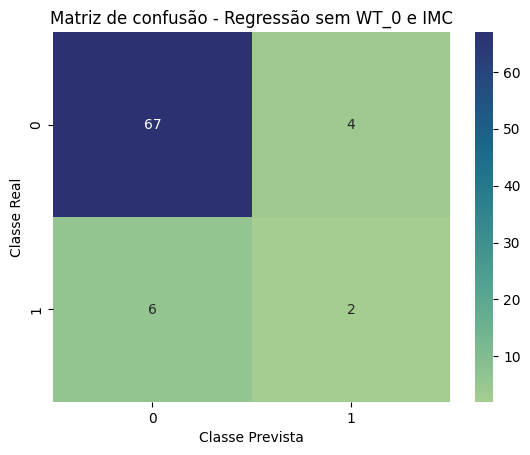

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93        71
         1.0       0.33      0.25      0.29         8

    accuracy                           0.87        79
   macro avg       0.63      0.60      0.61        79
weighted avg       0.86      0.87      0.87        79

AUC sem WT_0 e IMC: 0.7517605633802816
=== Stratified K-fold (sem WT_0) ===
              precision    recall  f1-score   support

         0.0     0.9084    0.9661    0.9363       236
         1.0     0.2727    0.1154    0.1622        26

    accuracy                         0.8817       262
   macro avg     0.5905    0.5407    0.5493       262
weighted avg     0.8453    0.8817    0.8595       262



c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [113]:
# preparar os dados para treinar o modelo sem WT_0 e IMC
x_train_sem_compostas = X_train.drop(['WT_0','IMC'], axis=1)
x_test_sem_compostas = X_test.drop(['WT_0','IMC'], axis=1)

# Treino do modelo sem WT_0 e IMC
clf_LR_sem_compostas = LogisticRegression(random_state=42)
clf_LR_sem_compostas = clf_LR_sem_compostas.fit(x_train_sem_compostas, y_train)

# previsões
y_pred_LR_sem_compostas = clf_LR_sem_compostas.predict(x_test_sem_compostas)

#avaliação de métricas para o modelo sem WT_0 e IMC
#matriz de confusao para o modelo sem WT_0 e IMC
confusion_sem_compostas = confusion_matrix(y_test, y_pred_LR_sem_compostas)
sns.heatmap(confusion_sem_compostas, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão sem WT_0 e IMC")
plt.show()

#curva ROC e AUC para o modelo sem WT_0 e IMC
print(classification_report(y_test, y_pred_LR_sem_compostas))
y_proba_LR_sem_compostas = clf_LR_sem_compostas.predict_proba(x_test_sem_compostas)[:, 1]
auc_sem_compostas = roc_auc_score(y_test, y_proba_LR_sem_compostas)

print("AUC sem WT_0 e IMC:", auc_sem_compostas)

# k-fold estratificado para o modelo sem WT_0 e IMC
pred_cross_sem_compostas = cross_val_predict(
    clf_LR_sem_compostas,
    X.drop(['WT_0','IMC'], axis=1),
    y,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
)
print("=== Stratified K-fold (sem WT_0) ===")
print(classification_report(y, pred_cross_sem_compostas, digits=4))

# 5) Avaliação de impacto de scaling

In [114]:
# definir as colunas numéricas para aplicar o scaling
cols_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
# aplicar o StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])

X_test_scaled = X_test.copy()
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

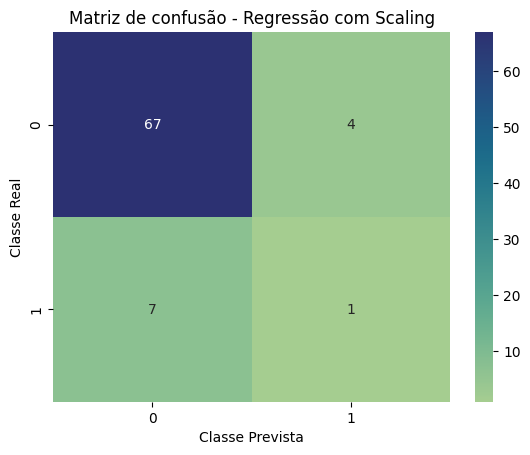

              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92        71
         1.0       0.20      0.12      0.15         8

    accuracy                           0.86        79
   macro avg       0.55      0.53      0.54        79
weighted avg       0.83      0.86      0.85        79

AUC com Scaling: 0.7235915492957747
=== Stratified K-fold (com Scaling) ===
              precision    recall  f1-score   support

         0.0     0.9153    0.9818    0.9474       165
         1.0     0.5000    0.1667    0.2500        18

    accuracy                         0.9016       183
   macro avg     0.7076    0.5742    0.5987       183
weighted avg     0.8744    0.9016    0.8788       183



In [115]:
# Treino do modelo com scaling
clf_LR_scaled = LogisticRegression(random_state=42)
clf_LR_scaled = clf_LR_scaled.fit(X_train_scaled, y_train)
# previsões
y_pred_LR_scaled = clf_LR_scaled.predict(X_test_scaled)

# avaliação de métricas para o modelo com scaling
# matriz de confusão para o modelo com scaling
confusion_scaled = confusion_matrix(y_test, y_pred_LR_scaled)
sns.heatmap(confusion_scaled, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão com Scaling")
plt.show()
# curva ROC e AUC para o modelo com scaling

print(classification_report(y_test, y_pred_LR_scaled))
y_proba_LR_scaled = clf_LR_scaled.predict_proba(X_test_scaled)[:, 1]
auc_scaled = roc_auc_score(y_test, y_proba_LR_scaled)

print("AUC com Scaling:", auc_scaled)
# K-fold estratificado para o modelo com scaling
pred_cross_scaled = cross_val_predict(
    clf_LR_scaled,
    X_train_scaled,
    y_train,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)
print("=== Stratified K-fold (com Scaling) ===")
print(classification_report(y_train, pred_cross_scaled, digits=4))

In [116]:
# avaliar a importância das features no modelo com scaling
coef_LR_scaled = pd.DataFrame({
    'Variavel': X_train_scaled.columns,
    'Coeficiente': clf_LR_scaled.coef_[0]
}).sort_values(by='Coeficiente', key=abs, ascending=False)
coef_LR_scaled.head(10)

,Variavel,Coeficiente
7,PM6_0,1.146302
5,Fle_0,1.004462
12,Grupo_pre_2,0.923718
13,Grupo_pre_3,-0.739975
4,IMC,-0.700545
14,Grupo_pre_4,-0.687500
0,Idade,-0.565425
2,Peso,-0.561741
15,Grupo_pre_5,0.457881
18,Grupo_pre_8,0.362805


# 6) Optimização de pârametros utilizando Grid_search

In [123]:
#avaliação de melhores parametros para o modelo com grid search
param_grid = {
    'C': [ 0.1, 1, 2, 5],
    'penalty': [ 'l1','l2', 'none' ],
    'solver': [ 'liblinear', 'lbfgs'],
    'class_weight': ['balanced', {0:1, 1:3}, {0:1, 1:10}, None]
}
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
print("Melhores parâmetros:", grid_search.best_params_)


Melhores parâmetros: {'C': 0.1, 'class_weight': {0: 1, 1: 10}, 'penalty': 'l1', 'solver': 'liblinear'}


c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
240 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\edu23\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solv

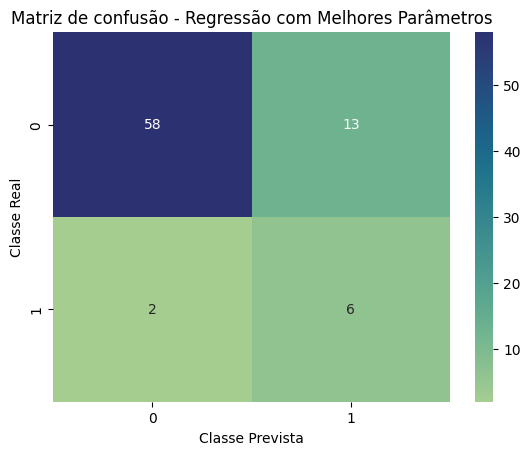

              precision    recall  f1-score   support

         0.0       0.97      0.82      0.89        71
         1.0       0.32      0.75      0.44         8

    accuracy                           0.81        79
   macro avg       0.64      0.78      0.66        79
weighted avg       0.90      0.81      0.84        79

AUC com Melhores Parâmetros: 0.7711267605633803


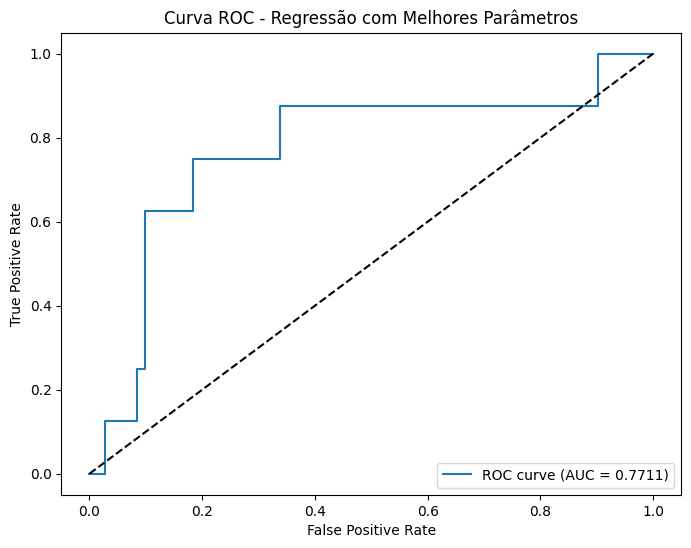

=== Stratified K-fold (com Melhores Parâmetros) ===
              precision    recall  f1-score   support

         0.0     0.9504    0.8121    0.8758       165
         1.0     0.2619    0.6111    0.3667        18

    accuracy                         0.7923       183
   macro avg     0.6061    0.7116    0.6212       183
weighted avg     0.8826    0.7923    0.8257       183



In [124]:
# aplicação dos melhores parâmetros encontrados
clf_LR_tuned = LogisticRegression(
    random_state=42,
    C=1,
    penalty='l1',
    solver='liblinear',
    class_weight= {0:1, 1:10}
)
clf_LR_tuned = clf_LR_tuned.fit(X_train_scaled, y_train)
y_pred_LR_tuned = clf_LR_tuned.predict(X_test_scaled)
# avaliação de métricas para o modelo com os melhores parâmetros
# matriz de confusão para o modelo com os melhores parâmetros
confusion_tuned = confusion_matrix(y_test, y_pred_LR_tuned)
sns.heatmap(confusion_tuned, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de confusão - Regressão com Melhores Parâmetros")
plt.show()

# curva ROC e AUC para o modelo com os melhores parâmetros
print(classification_report(y_test, y_pred_LR_tuned))
# cálculo da AUC para o modelo com os melhores parâmetros
y_proba = clf_LR_tuned.predict_proba(X_test_scaled)[:, 1]
auc_tuned = roc_auc_score(y_test, y_proba)
print("AUC com Melhores Parâmetros:", auc_tuned)

#gráfico com curva AUC para o modelo com os melhores parâmetros
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # linha de referência
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regressão com Melhores Parâmetros')
plt.legend(loc='lower right')
plt.show()
# K-fold estratificado para o modelo com os melhores parâmetros
pred_cross_tuned = cross_val_predict(
    clf_LR_tuned,
    X_train_scaled,
    y_train,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)    
)
print("=== Stratified K-fold (com Melhores Parâmetros) ===")
print(classification_report(y_train, pred_cross_tuned, digits=4))

In [119]:
# avaliação do impacto de threshold
# 1. Probabilidades da classe 1
y_proba = clf_LR_tuned.predict_proba(X_train_scaled)[:, 1]

# 2. Thresholds a testar
thresholds = np.arange(0.1, 0.6, 0.05)

print("thr | precision | recall | f1")

# 3. Loop
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    p = precision_score(y_train, y_pred, zero_division=0)
    r = recall_score(y_train, y_pred, zero_division=0)
    f1 = f1_score(y_train, y_pred, zero_division=0)
    
    print(f"{t:.2f} | {p:.2f} | {r:.2f} | {f1:.2f}")


thr | precision | recall | f1
0.10 | 0.17 | 1.00 | 0.29
0.15 | 0.20 | 1.00 | 0.33
0.20 | 0.22 | 1.00 | 0.36
0.25 | 0.24 | 1.00 | 0.39
0.30 | 0.26 | 1.00 | 0.41
0.35 | 0.28 | 1.00 | 0.44
0.40 | 0.31 | 1.00 | 0.47
0.45 | 0.33 | 1.00 | 0.50
0.50 | 0.31 | 0.89 | 0.46
0.55 | 0.35 | 0.83 | 0.49


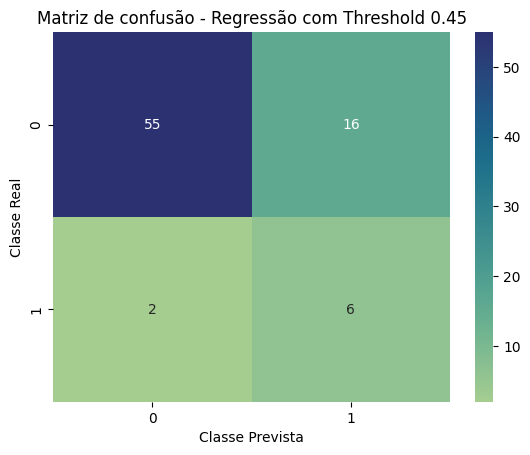

              precision    recall  f1-score   support

         0.0       0.96      0.77      0.86        71
         1.0       0.27      0.75      0.40         8

    accuracy                           0.77        79
   macro avg       0.62      0.76      0.63        79
weighted avg       0.89      0.77      0.81        79

AUC: 0.7711267605633803
=== Stratified K-fold ===
              precision    recall  f1-score   support

         0.0     0.9504    0.8121    0.8758       165
         1.0     0.2619    0.6111    0.3667        18

    accuracy                         0.7923       183
   macro avg     0.6061    0.7116    0.6212       183
weighted avg     0.8826    0.7923    0.8257       183



In [125]:
clf_LR_tuned = LogisticRegression(
    random_state=42,
    C=1,
    penalty='l1',
    solver='liblinear',
    class_weight= {0:1, 1:10},
    max_iter=1000
)

clf_LR_tuned.fit(X_train_scaled, y_train)

# probabilidades
y_proba_LR_tuned = clf_LR_tuned.predict_proba(X_test_scaled)[:, 1]

threshold = 0.45

y_pred_LR_tuned = (y_proba_LR_tuned >= threshold).astype(int)

# matriz de confusão
confusion_tuned_threshold = confusion_matrix(y_test, y_pred_LR_tuned)
sns.heatmap(confusion_tuned_threshold, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title(f"Matriz de confusão - Regressão com Threshold {threshold}")
plt.show()

# métricas
print(classification_report(y_test, y_pred_LR_tuned))

auc = roc_auc_score(y_test, y_proba_LR_tuned)
print("AUC:", auc)

# cross-validation (sem threshold custom)
pred_cross = cross_val_predict(
    LogisticRegression(
        random_state=42,
        C=1,
        penalty='l1',
        solver='liblinear',
        class_weight= {0:1, 1:10},
        max_iter=1000
    ),
    X_train_scaled,
    y_train,
    cv=sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print("=== Stratified K-fold ===")
print(classification_report(y_train, pred_cross, digits=4))



# 7) modelo Final 

Treino e teste do modelo final com as hipoteses encontradas através de grid search e procura de um melhor Threshold

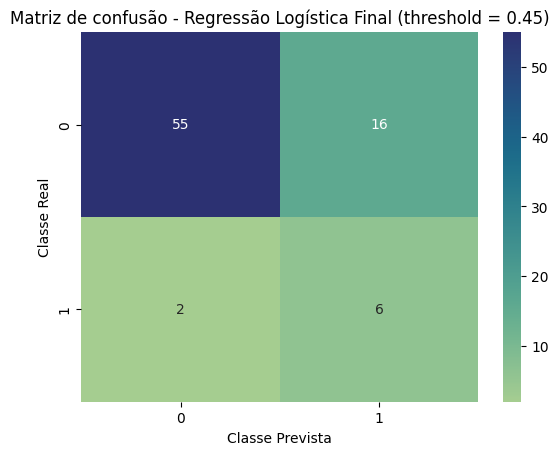

=== Avaliação no conjunto de teste ===
              precision    recall  f1-score   support

         0.0     0.9649    0.7746    0.8594        71
         1.0     0.2727    0.7500    0.4000         8

    accuracy                         0.7722        79
   macro avg     0.6188    0.7623    0.6297        79
weighted avg     0.8948    0.7722    0.8129        79

AUC: 0.7711267605633803


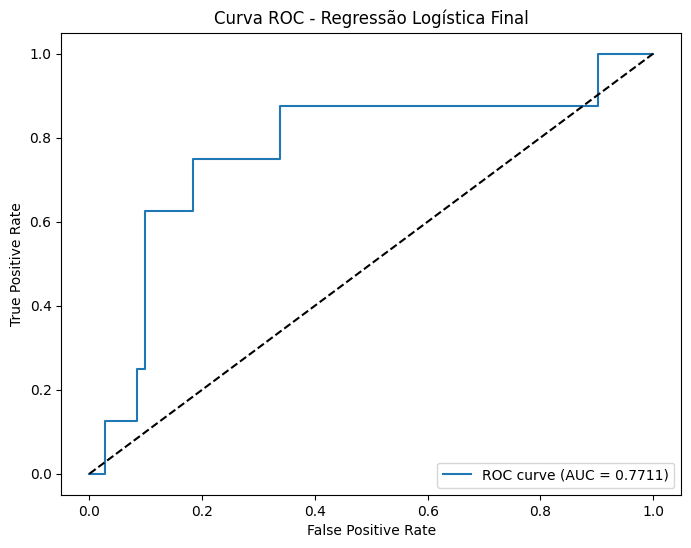

In [126]:

# 1. Definição do modelo final com os melhores hiperparâmetros
clf_LR_final = LogisticRegression(
    random_state=42,
    C=1,
    penalty='l1',
    solver='liblinear',
    class_weight={0:1, 1:10},
    max_iter=1000
)

# 2. Treino do modelo no conjunto de treino
clf_LR_final.fit(X_train_scaled, y_train)

# 3. Definição do threshold final
threshold = 0.45  

# 4. Probabilidades da classe positiva no conjunto de teste
y_proba_LR_final = clf_LR_final.predict_proba(X_test_scaled)[:, 1]

# 5. Conversão das probabilidades em classes com o threshold definido
y_pred_LR_final = (y_proba_LR_final >= threshold).astype(int)


# Matriz de confusão
confusion_final = confusion_matrix(y_test, y_pred_LR_final)

sns.heatmap(confusion_final, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title(f"Matriz de confusão - Regressão Logística Final (threshold = {threshold})")
plt.show()

# Métricas de classificação
print("=== Avaliação no conjunto de teste ===")
print(classification_report(y_test, y_pred_LR_final, digits=4))

# AUC
auc_final = roc_auc_score(y_test, y_proba_LR_final)
print("AUC:", auc_final)

# Curva ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_LR_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_final:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regressão Logística Final')
plt.legend(loc='lower right')
plt.show()